# 1. Executive Summary & Objective
This project is inspired by how traditional Generalized Linear Models (GLMs) ignore non-linear risk interactions and result in lower portfolio profitability in the insurance industry. Thus, this notebook trains a traditional GLM and a XGBoost challenger model, and evaluates their performance through the Actuarial Double Lift Chart and Gini Index. Due to its better ability in predicting premium, the XGBoost model is saved and used to develop the Actuarial Pricing Engine web app.

# 2. Data Loading & Preprocessing

In [19]:
import pandas as pd
from sklearn.datasets import fetch_openml

try:
    print("Attempting to connect to OpenML...")
    # Fetch the French Motor Third-Party Liability Dataset
    motor_data = fetch_openml(data_id=41106, as_frame=True).frame
    print("Success! Dataset loaded from OpenML.")

except Exception as e:
    print(f"OpenML failed with error: {e}")
    print("Switching to backup GitHub mirror...")

    # Fallback to a direct public mirror of the Frequency dataset
    backup_url = "https://raw.githubusercontent.com/Karol-Gawlowski/ADSWP_NN/main/freMTPL2freq.csv"
    motor_data = pd.read_csv(backup_url)
    print("Success! Dataset loaded from backup mirror.")

# Inspect the first 5 rows to confirm it is loaded
motor_data.head()

Attempting to connect to OpenML...
OpenML failed with error: Dataset with data_id 41106 not found.
Switching to backup GitHub mirror...
Success! Dataset loaded from backup mirror.


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


External APIs can experience latency or downtime (as seen in the OpenML timeout below). To ensure this notebook runs reproducibly for any reviewer, I have engineered a try...except fallback mechanism that automatically reroutes the data ingestion to a stable GitHub mirror if the primary server fails.

In [20]:

print("Attempting to connect to OpenML...")
try:
    # Method 1: Fetch by exact dataset name and version (Much more reliable than ID)
    # Note: parser='auto' is added to suppress future warnings in scikit-learn
    severity_data = fetch_openml(name="freMTPL2sev", version=1, as_frame=True, parser='auto').frame
    print("Success! Severity data loaded from OpenML.")

except Exception as e:
    print(f"OpenML failed. Switching to Hugging Face Enterprise Mirror...")

    # Method 2: Fallback to a permanent Hugging Face raw CSV link
    hf_url = "https://huggingface.co/datasets/mabilton/fremtpl2/resolve/main/freMTPL2sev.csv"
    severity_data = pd.read_csv(hf_url)
    print("Success! Dataset loaded from Hugging Face mirror.")

# 2. Aggregate the claims
# A single driver might have 2 accidents in one year. We need to sum their total claim amounts.
severity_grouped = severity_data.groupby('IDpol')['ClaimAmount'].sum().reset_index()

# 3. Merge (Join) the two datasets together based on the 'IDpol' column
# We use a 'left' join so we don't lose the 95% of drivers who didn't have an accident
motor_data = pd.merge(motor_data, severity_grouped, on='IDpol', how='left')

# 4. Clean up the missing values
# Drivers with no accidents and thus no claims will have 'NaN' for ClaimAmount. We set these to 0.
motor_data['ClaimAmount'] = motor_data['ClaimAmount'].fillna(0)

# Inspect the fixed dataframe!
motor_data.head()

Attempting to connect to OpenML...
Success! Severity data loaded from OpenML.


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82,0.0
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82,0.0
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22,0.0
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72,0.0
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72,0.0


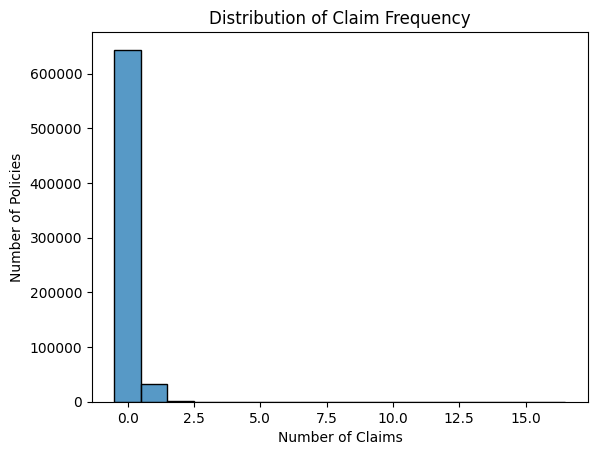

In [21]:
# Import the necessary plotting packages
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the histogram for Claim Frequency (ClaimNb)
sns.histplot(motor_data['ClaimNb'], bins=10, discrete=True)

# Add professional labels
plt.title('Distribution of Claim Frequency')
plt.xlabel('Number of Claims')
plt.ylabel('Number of Policies')

# Display the plot cleanly
plt.show()

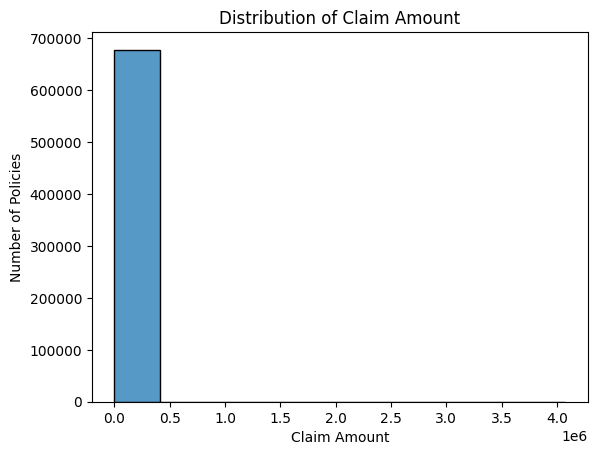

In [22]:
import math

sns.histplot(motor_data['ClaimAmount'], bins=10, discrete=False)
plt.title('Distribution of Claim Amount')
plt.xlabel('Claim Amount')
plt.ylabel('Number of Policies')

# Display the plot cleanly
plt.show()

# 3. The Baseline: Traditional GLM (Gamma/Poisson)

Although GLMs are generally the industry standard, they often miss non-linear risk interactions, which would be covered by the XGBoost Model trained later.

In [23]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

# Define the GLM
formula_freq = "ClaimNb ~ VehPower + DrivAge + BonusMalus"

# Fit the model using a Poisson distribution and a log link
model_freq = smf.glm(formula=formula_freq,
                     data=motor_data,
                     offset=np.log(motor_data['Exposure']),
                     family=sm.families.Poisson(link=sm.families.links.Log())).fit()

# View the statistical summary (p-values, coefficients)
print(model_freq.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   678009
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4451e+05
Date:                Fri, 05 Jun 2026   Deviance:                   2.1970e+05
Time:                        12:57:34   Pearson chi2:                 2.00e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.007022
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.1192      0.037   -112.005      0.0

In [24]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# 1. Filter data to only those who had claims AND where the claim cost something
data_with_claims = motor_data[(motor_data['ClaimNb'] > 0) & (motor_data['ClaimAmount'] > 0)].copy()

# 2. Define the formula (predicting the cost of the claim)
formula_cost = "ClaimAmount ~ VehPower + DrivAge + BonusMalus"

# 3. Fit the Gamma GLM (Notice: No offset!)
model_cost_of_claim = smf.glm(formula=formula_cost,
                              data=data_with_claims,
                              family=sm.families.Gamma(link=sm.families.links.Log())).fit()

# 4. View the results
print(model_cost_of_claim.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            ClaimAmount   No. Observations:                24944
Model:                            GLM   Df Residuals:                    24940
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                          76.504
Method:                          IRLS   Log-Likelihood:            -2.8202e+05
Date:                Fri, 05 Jun 2026   Deviance:                       42753.
Time:                        12:57:34   Pearson chi2:                 1.91e+06
No. Iterations:                    23   Pseudo R-squ. (CS):          0.0008347
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.9797      0.397     17.568      0.0

In [25]:
# 1. Predict Frequency for all 100,000 rows at once
motor_data['Predicted_Freq'] = model_freq.predict(motor_data)*motor_data['Exposure']

# 2. Predict Severity for all 100,000 rows at once
motor_data['Predicted_Seve'] = model_cost_of_claim.predict(motor_data)

# 3. Calculate the Pure Premium using vectorized multiplication
motor_data['Pure_Premium'] = motor_data['Predicted_Freq'] * motor_data['Predicted_Seve']

# 4. View the results for the first 5 drivers
motor_data[['Exposure', 'VehPower', 'DrivAge', 'BonusMalus', 'Pure_Premium']].head()


,Exposure,VehPower,DrivAge,BonusMalus,Pure_Premium
0,0.10,5,55,50,15.194733
1,0.77,5,55,50,116.999447
2,0.75,6,52,50,118.998520
3,0.09,7,46,50,14.715030
4,0.84,7,46,50,137.340282


# 4. The Challenger: XGBoost Architecture

In [26]:
import xgboost as xgb

# 1. Prepare features (X) and target (y)
X = motor_data[['VehPower', 'DrivAge', 'BonusMalus']]
y_freq = motor_data['ClaimNb']

# 2. Set the XGBoost parameters for Frequency
params_freq = {
    'objective': 'count:poisson',  # Matches our GLM Poisson family
    'learning_rate': 0.1,
    'max_depth': 3,                 # Keep trees shallow to prevent overfitting
    'seed':42
}

# 3. Create the DMatrix (XGBoost's highly optimized data structure)
dtrain_freq = xgb.DMatrix(X, label=y_freq)
dtrain_freq.set_base_margin(np.log(motor_data['Exposure']))
#Log(Exposure) is used as the base margin to avoid dealing with negative Exposure

# 4. Train the challenger model
xgb_freq_model = xgb.train(params_freq, dtrain_freq, num_boost_round=100)

In [27]:
# Create a new dataframe containing ONLY drivers who had an accident
severity_data_xgb = motor_data[(motor_data['ClaimNb'] > 0) & (motor_data['ClaimAmount'] > 0)].copy()

X = severity_data_xgb[['VehPower', 'DrivAge', 'BonusMalus']]
y_seve = severity_data_xgb['ClaimAmount']

dtrain_seve = xgb.DMatrix(X, label=y_seve)

#Find the average cost of a claim to give XGBoost a head start
average_claim_cost = y_seve.mean()

#Update the parameters with the magic 'base_score' fix
params_seve = {
    'objective': 'reg:gamma',
    'learning_rate': 0.1,
    'max_depth': 3,
    'base_score': average_claim_cost,  #Start guessing at the average
    'seed':42
    }

#Retrain the severity model
print(f"Training XGBoost Severity with base_score = {average_claim_cost:.2f}...")
xgb_seve_model = xgb.train(params_seve, dtrain_seve, num_boost_round=100)

Training XGBoost Severity with base_score = 2401.75...


In [28]:
# 1. Define the exact same feature columns used for training
X_portfolio = motor_data[['VehPower', 'DrivAge', 'BonusMalus']]

# Package the features into a DMatrix
dpred_freq = xgb.DMatrix(X_portfolio)

#  Apply the Exposure offset so it predicts for the correct time period
dpred_freq.set_base_margin(np.log(motor_data['Exposure']))

# Predict and save to the dataframe
motor_data['XGB_Freq'] = xgb_freq_model.predict(dpred_freq)

In [29]:
dpred_seve = xgb.DMatrix(X_portfolio)

motor_data['XGB_Seve'] = xgb_seve_model.predict(dpred_seve)

In [30]:
motor_data['XGB_Pure_premium'] = motor_data['XGB_Freq']*motor_data['XGB_Seve']

motor_data[['Exposure','Pure_Premium','XGB_Pure_premium']].head()

,Exposure,Pure_Premium,XGB_Pure_premium
0,0.10,15.194733,16.871252
1,0.77,116.999447,129.908569
2,0.75,118.998520,146.536316
3,0.09,14.715030,16.757362
4,0.84,137.340282,156.401855


In [31]:
# 1. The Portfolio Reality Check (Macro Level)
print("--- PORTFOLIO AVERAGES ---")
print(f"GLM Average Premium:    ${motor_data['Pure_Premium'].mean():.2f}")
print(f"XGB Average Premium:    ${motor_data['XGB_Pure_premium'].mean():.2f}")

# 2. The Component Check (Micro Level - First 5 rows)
print("\n--- COMPONENT BREAKDOWN (First 5 Rows) ---")
print(motor_data[['Predicted_Freq', 'XGB_Freq', 'Predicted_Seve', 'XGB_Seve']].head())

--- PORTFOLIO AVERAGES ---
GLM Average Premium:    $124.79
XGB Average Premium:    $118.38

--- COMPONENT BREAKDOWN (First 5 Rows) ---
   Predicted_Freq  XGB_Freq  Predicted_Seve     XGB_Seve
0        0.008265  0.008767     1838.519250  1924.387817
1        0.063638  0.067506     1838.519250  1924.387817
2        0.061731  0.070031     1927.688611  2092.453125
3        0.007218  0.008404     2038.764944  1994.042847
4        0.067364  0.078435     2038.764944  1994.042847


# 5. Financial Evaluation: Lift Charts & Gini Index

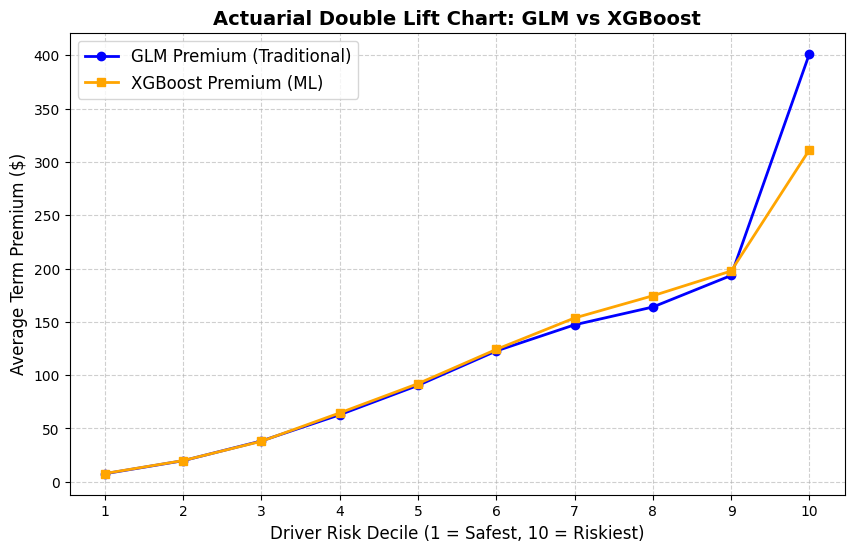

In [32]:
# 1. Sort the dataset by the GLM's predicted Pure Premium (safest to riskiest)
motor_data_sorted = motor_data.sort_values(by='Pure_Premium')

# 2. Break the sorted data into 10 equal buckets (Deciles)
motor_data_sorted['Decile'] = pd.qcut(np.arange(len(motor_data_sorted)), 10, labels=False) + 1

# 3. Calculate the average premium for each model inside each decile
lift_data = motor_data_sorted.groupby('Decile')[['Pure_Premium', 'XGB_Pure_premium']].mean()

# 4. Plot the Double Lift Chart
plt.figure(figsize=(10, 6))
plt.plot(lift_data.index, lift_data['Pure_Premium'], marker='o', linewidth=2, label='GLM Premium (Traditional)', color='blue')
plt.plot(lift_data.index, lift_data['XGB_Pure_premium'], marker='s', linewidth=2, label='XGBoost Premium (ML)', color='orange')

# 5. Make it look professional
plt.title('Actuarial Double Lift Chart: GLM vs XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Driver Risk Decile (1 = Safest, 10 = Riskiest)', fontsize=12)
plt.ylabel('Average Term Premium ($)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.show()

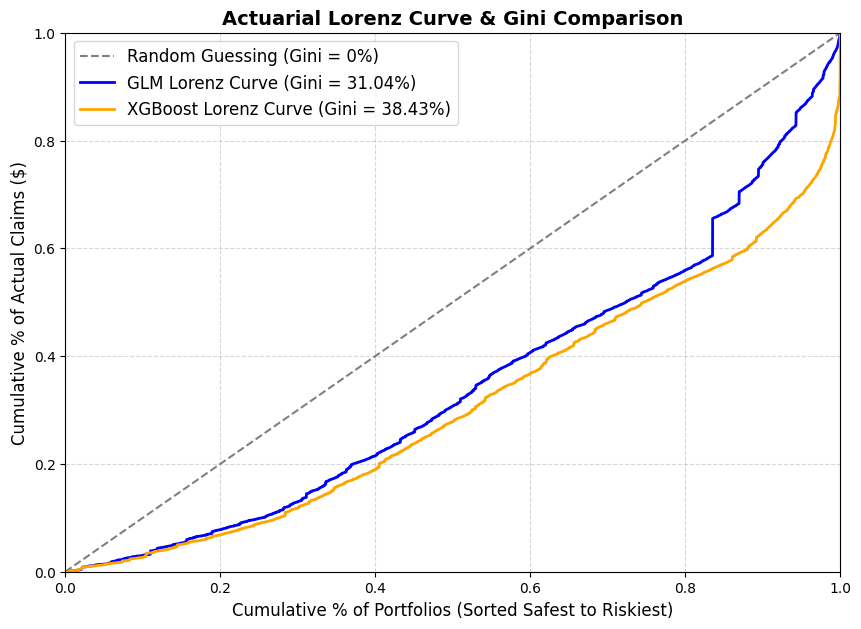

GLM Gini Index:     31.04%
XGBoost Gini Index: 38.43%
Absolute Lift:      7.39% percentage points


In [33]:
def get_lorenz_curve(df, premium_col, loss_col):
    """
    Sorts the dataframe by predicted premium (safest to riskiest)
    and calculates cumulative population and loss percentages.
    """
    # 1. Sort ascending by the model's predicted risk
    df_sorted = df.sort_values(by=premium_col).copy()

    # 2. Calculate cumulative percentage of the population (X-axis)
    cum_pop = np.arange(1, len(df_sorted) + 1) / len(df_sorted)

    # 3. Calculate cumulative percentage of actual historical losses (Y-axis)
    cum_losses = df_sorted[loss_col].cumsum() / df_sorted[loss_col].sum()

    # 4. Calculate Gini Index: 1 - 2 * (Area Under the Lorenz Curve)
    area_under_curve = np.trapezoid(cum_losses, cum_pop)
    gini_index = 1 - 2 * area_under_curve

    return cum_pop, cum_losses, gini_index

# Run the function for both models using 'ClaimAmount' as the ground truth loss
pop_glm, loss_glm, gini_glm = get_lorenz_curve(motor_data, 'Pure_Premium', 'ClaimAmount')
pop_xgb, loss_xgb, gini_xgb = get_lorenz_curve(motor_data, 'XGB_Pure_premium', 'ClaimAmount')

# Plotting the Masterpiece
plt.figure(figsize=(10, 7))

# Plot Perfect Equality (Random Guessing Baseline)
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1.5, label='Random Guessing (Gini = 0%)')

# Plot GLM and XGBoost Lorenz Curves
plt.plot(pop_glm, loss_glm, color='blue', linewidth=2, label=f'GLM Lorenz Curve (Gini = {gini_glm*100:.2f}%)')
plt.plot(pop_xgb, loss_xgb, color='orange', linewidth=2, label=f'XGBoost Lorenz Curve (Gini = {gini_xgb*100:.2f}%)')

# Formatting
plt.title('Actuarial Lorenz Curve & Gini Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Cumulative % of Portfolios (Sorted Safest to Riskiest)', fontsize=12)
plt.ylabel('Cumulative % of Actual Claims ($)', fontsize=12)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12, loc='upper left')

plt.show()

print(f"GLM Gini Index:     {gini_glm*100:.2f}%")
print(f"XGBoost Gini Index: {gini_xgb*100:.2f}%")
print(f"Absolute Lift:      {(gini_xgb - gini_glm)*100:.2f}% percentage points")

The higher Gini index and Lift for the XGBoost Model means it is significantly better than the GLM at identifying heavily underpriced risky drivers and overpriced safe drivers, allowing the company to optimize its ratebook and win market share.

# 6. Regulatory Compliance: Explainable AI (SHAP)
Integrating SHAP ensures our pricing models meet strict regulatory guidelines for fairness and transparency, allowing underwriters to mathematically justify premium changes to both clients and regulators."

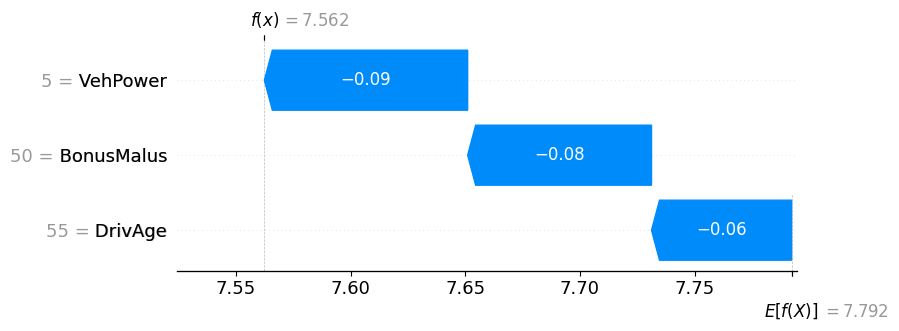

In [34]:
!pip install shap
import shap

# Initialize the javascript visualization library for Colab
shap.initjs()

# 1. We use a TreeExplainer because XGBoost is a tree-based model
# We will explain the Severity model as an example
explainer = shap.TreeExplainer(xgb_seve_model)

# 2. Calculate the SHAP values for the first driver (Row 0)
# Remember, X_portfolio contains our numeric features: ['VehPower', 'DrivAge', 'BonusMalus']
shap_values = explainer(X_portfolio.iloc[0:1])

# 3. Plot the Waterfall chart for this specific driver
shap.plots.waterfall(shap_values[0])

# 7. Model Serialization (Deployment Prep)



In [35]:
import pickle

# 1. Save the XGBoost Frequency Model
with open('xgb_freq_model.pkl', 'wb') as f:
    pickle.dump(xgb_freq_model, f)

# 2. Save the XGBoost Severity Model
with open('xgb_seve_model.pkl', 'wb') as f:
    pickle.dump(xgb_seve_model, f)

print("Models successfully saved as .pkl files!")

Models successfully saved as .pkl files!
